# Recurso descargable: `MLPClassifier` sobre el dataset Iris

**Módulo 06 — Fundamentos de redes neuronales.** Este es el recurso descargable de la clase (`OD_RN1_ESP_M03_S10`). El notebook original venía con 25 celdas de código y ninguna celda de texto; esta versión agrega explicaciones en las celdas markdown intercaladas, sin tocar el código ni los resultados que ya estaban calculados.

El recurso se organiza en tres bloques:

1. **MLPClassifier básico** sobre Iris (dos atributos, tres clases): entrenamiento, predicción, región de decisión, matriz de confusión.
2. **Funciones de activación, arquitectura y parada temprana**: comparación `logistic` / `tanh` / `relu`, una red más grande con `verbose` y `n_iter_no_change`, y la curva de pérdida.
3. **Optimización y regularización**: barrido de `alpha`, comparación de solvers (`sgd`, `adam`, `lbfgs`) y búsqueda de hiperparámetros con `GridSearchCV`.

Una advertencia general antes de empezar: **el notebook no escala los datos** (no usa `StandardScaler` en ningún momento). El MLP es sensible a la escala de los atributos porque el descenso por gradiente avanza distinto en cada dirección según la magnitud de los valores de entrada. En el notebook propio [`funciones_activacion.ipynb`](funciones_activacion.ipynb) de este mismo módulo se compara el mismo tipo de red con y sin escalado, y se ve el efecto. Acá se deja tal cual vino el recurso, pero conviene tenerlo presente al leer los resultados.

## Importar librerías

In [1]:
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar el dataset

Se usa el dataset **Iris**, clásico para clasificación multiclase: 150 muestras, 4 atributos numéricos (largo y ancho de sépalo y pétalo) y 3 clases (*setosa*, *versicolor*, *virginica*), 50 muestras por clase.

In [2]:
#Cargar el dataset
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

## Explorar el dataset como DataFrame

Se arma un `DataFrame` de pandas con los 4 atributos y se agrega la columna `target` con la clase (0, 1 o 2) para poder filtrar y graficar más fácil.

In [3]:
#Leer el dataset
data_df = pd.DataFrame(iris.data, columns=iris.feature_names)
data_df["target"] = iris.target

data_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Seleccionar dos atributos

Para poder graficar la frontera de decisión en dos dimensiones, el notebook se queda con solo dos de los cuatro atributos: **largo de sépalo** (`sepal length`) y **largo de pétalo** (`petal length`). Es una decisión práctica para poder visualizar, no una limitación del modelo: el MLP podría entrenarse igual con los cuatro atributos.

In [4]:
#Seleccionar columnas
columns = ["sepal length (cm)", "petal length (cm)", "target"]
#columns = ["sepal width (cm)", "petal width (cm)", "target"]
data_df = data_df[columns]
data_df.tail(5)

,sepal length (cm),petal length (cm),target
145,6.7,5.2,2
146,6.3,5.0,2
147,6.5,5.2,2
148,6.2,5.4,2
149,5.9,5.1,2


## Visualizar las tres clases

Un scatter plot de los dos atributos elegidos, coloreando cada clase distinto. Sirve para ver de entrada qué tan separables son las clases con esta elección de atributos: si se solapan, un modelo lineal simple no alcanza y se justifica usar una red con capas ocultas.

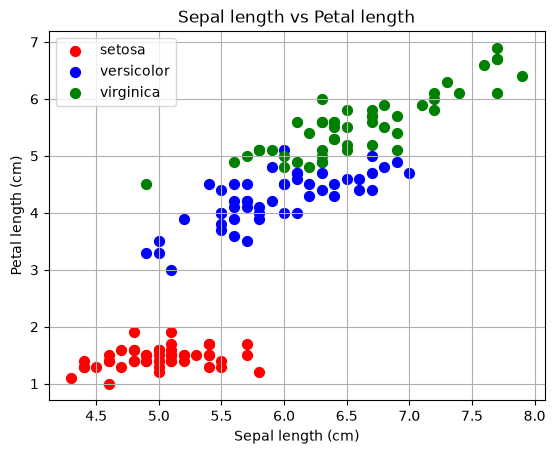

In [5]:
#Visualizar datos
plt.figure()
#Datos de iris setosa
setosa_data = data_df[data_df["target"] == 0]
#Datos de iris versicolor
versicolor_data = data_df[data_df["target"] == 1]
#Datos de iris virginica
virginica_data = data_df[data_df["target"] == 2]

#Graficar los datos
plt.scatter(setosa_data["sepal length (cm)"], setosa_data["petal length (cm)"], label="setosa", color="red", s=50)
plt.scatter(versicolor_data["sepal length (cm)"], versicolor_data["petal length (cm)"], label="versicolor", color="blue", s=50)
plt.scatter(virginica_data["sepal length (cm)"], virginica_data["petal length (cm)"], label="virginica", color="green", s=50)

#plt.scatter(setosa_data["sepal width (cm)"], setosa_data["petal width (cm)"], label="setosa", color="red", s=50)
#plt.scatter(versicolor_data["sepal width (cm)"], versicolor_data["petal width (cm)"], label="versicolor", color="blue", s=50)
#plt.scatter(virginica_data["sepal width (cm)"], virginica_data["petal width (cm)"], label="virginica", color="green", s=50)

plt.title("Sepal length vs Petal length")
plt.xlabel('Sepal length (cm)')
plt.ylabel('Petal length (cm)')

#plt.title("Sepal width vs Petal width")
#plt.xlabel('Sepal width (cm)')
#plt.ylabel('Petal width (cm)')

plt.grid()
plt.legend()
plt.show()


## Separar atributos (X) y etiqueta (y)

`X` queda con las dos columnas numéricas elegidas y `y` con la clase (0, 1, 2). Esta es la forma que espera `MLPClassifier`: `X` como matriz de atributos, `y` como vector de etiquetas.

In [6]:
X = data_df[["sepal length (cm)", "petal length (cm)"]].values
#print(X)

y = data_df["target"].values
print(y)


[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Dividir en entrenamiento y prueba

Split 80/20 con `random_state=42` fijo para que el resultado sea reproducible. El modelo se entrena solo con el 80% y se evalúa con el 20% restante, que la red no vio durante el entrenamiento.

In [7]:
#Dividir datos para entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entrenar el MLPClassifier

Se entrena una red con dos capas ocultas de 100 y 150 neuronas (`hidden_layer_sizes=(100, 150)`), activación `relu` y hasta 300 iteraciones (`max_iter=300`). `relu` (*rectified linear unit*) es la activación más usada en capas ocultas porque evita el problema de gradientes que se desvanecen, algo que sí sufren `logistic` y `tanh` en redes profundas.

In [8]:
mlp = MLPClassifier(hidden_layer_sizes=(100,150,), max_iter=300, activation='relu', random_state=42)
mlp.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


## Predecir sobre el conjunto de prueba

Se generan las predicciones del modelo sobre las 30 muestras de test y se comparan a simple vista contra las etiquetas reales.

In [9]:
#Predecir los datos del conjunto de prueba
y_pred = mlp.predict(X_test)
print(y_pred)
print(y_test)


[1 0 2 1 1 0 1 1 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


## Exactitud del modelo

`accuracy_score` calcula el porcentaje de predicciones correctas sobre el total. Es la métrica más simple para clasificación, pero hay que leerla con cuidado cuando el conjunto de test es chico (acá son solo 30 muestras): cada muestra que cambia de clase mueve la exactitud casi 3.3 puntos porcentuales, así que hay poca resolución para distinguir configuraciones parecidas. Esto se va a notar más adelante en la celda de `alpha`.

In [10]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Exactitud: {accuracy:.2f}%")

Exactitud: 96.67%


## Región de decisión

Se arma una grilla fina sobre el plano de los dos atributos y se le pide al modelo que prediga la clase en cada punto. Coloreando cada región según la clase predicha se ve la frontera que aprendió la red: a diferencia de un modelo lineal, el MLP puede curvar esa frontera para separar mejor clases que se solapan (como *versicolor* y *virginica*).

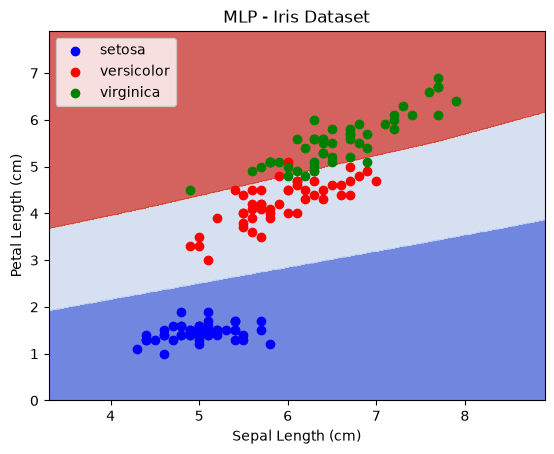

In [11]:
# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

## Matriz de confusión

La matriz de confusión muestra, para cada clase real (filas), cuántas muestras el modelo asignó a cada clase predicha (columnas). La diagonal son los aciertos; fuera de la diagonal, los errores. Es más informativa que la exactitud sola porque muestra *dónde* se equivoca el modelo, no solo cuánto.

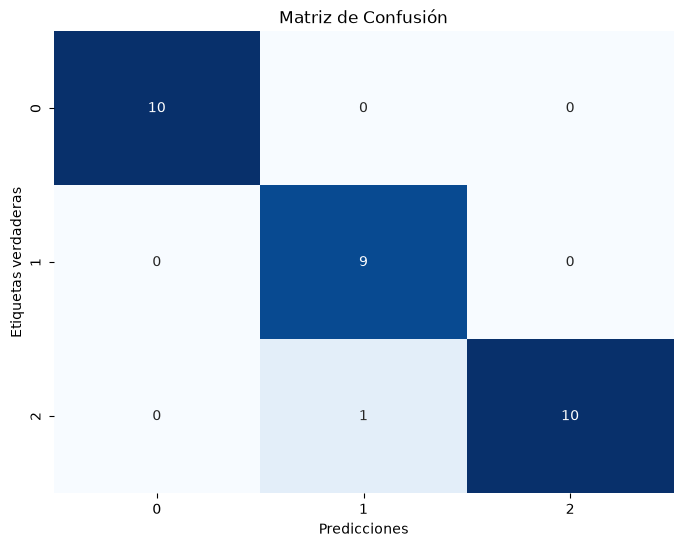

In [12]:
# Calculamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Creamos el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Etiquetas verdaderas')
plt.title('Matriz de Confusión')
plt.show()

## Reporte de clasificación

`classification_report` desglosa precisión, recall y f1-score por clase, además del promedio general. Sirve para ver si el modelo falla parejo en las tres clases o se concentra en una en particular (típicamente la que más se solapa con otra, como versicolor/virginica).

In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Comparar funciones de activación

Se entrena la misma arquitectura (una capa oculta de 100 neuronas) cambiando solo la función de activación: `logistic` (sigmoide), `tanh` y `relu`. Son las tres activaciones no lineales más comunes en capas ocultas:

- **logistic**: comprime la salida entre 0 y 1, históricamente la primera usada, pero satura y frena el aprendizaje en redes con varias capas.
- **tanh**: parecida pero centrada en cero (rango -1 a 1), converge un poco mejor que logistic por eso mismo.
- **relu**: no satura para valores positivos, más rápida de entrenar, es el estándar actual en la mayoría de las redes.

Con un problema tan simple como este (Iris con 2 atributos) es esperable que las tres den resultados parecidos; la diferencia entre activaciones se nota más en problemas grandes y redes profundas.

In [14]:
#Funciones de activación a evaluar
activations = ['logistic', 'tanh', 'relu']

#Diccionario para almacenar los resultados
results = {}

#Entrenar y evaluar el modelo con diferentes funciones de activación
for activation in activations:
    mlp = MLPClassifier(hidden_layer_sizes=(100,), activation=activation, max_iter=300, random_state=42)
    mlp.fit(X_train, y_train)
    
    y_pred = mlp.predict(X_test)
    
    #Calcular las métricas de rendimiento
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    #Almacenar los resultados
    results[activation] = {
        'accuracy' : accuracy,
        'classification_report' : report
    }

#Mostrar los resultados
for activation, metrics in results.items():
    print(f"Función de Activación: {activation}")
    print(f"Accuracy: {metrics['accuracy']}")
    print(f"Classification_report: \n{metrics['classification_report']}")
    print("-" * 60)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Función de Activación: logistic
Accuracy: 1.0
Classification_report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------------------------------------------------------------
Función de Activación: tanh
Accuracy: 0.9666666666666667
Classification_report: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

--------------------------

/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


## Una red más grande, con parada temprana

Esta celda entrena una red bastante más grande: tres capas ocultas de 100, 200 y 300 neuronas (`hidden_layer_sizes=(100, 200, 300)`), activación `relu`, hasta 400 iteraciones.

Dos parámetros nuevos controlan la **parada temprana** del entrenamiento:

- `n_iter_no_change=20`: si la pérdida no mejora en 20 iteraciones seguidas, el entrenamiento se corta antes de llegar a `max_iter`.
- `tol=1e-4`: qué tan chica tiene que ser la mejora para contar como "mejora" (si el cambio es menor a esta tolerancia, no cuenta).

`verbose=True` hace que la red imprima la pérdida en cada iteración, así se puede ver el progreso del entrenamiento en vivo.

> **Nota importante sobre el output guardado de esta celda y las siguientes (15 a 18):** el código de esta celda declara `hidden_layer_sizes=(100, 200, 300)` y `activation='relu'`, pero el output que quedó guardado (los `verbose` prints, la curva de pérdida, la región de decisión) corresponde a una corrida con `hidden_layer_sizes=(50, 50, 50)` y `activation='tanh'`. Es decir, el resultado que se ve más abajo **no coincide** con el código que está escrito en la celda. Si se re-ejecuta el notebook con el código tal como está, los números y el gráfico de pérdida van a salir distintos a lo que se ve guardado. Se deja constancia para no interpretar el output actual como si fuera fruto del código mostrado.

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(100,200,300), max_iter=400, activation='relu', random_state=42, verbose=True, n_iter_no_change=20, tol=1e-4)


mlp.fit(X_train, y_train)

Iteration 1, loss = 1.13219389
Iteration 2, loss = 1.03393776
Iteration 3, loss = 0.97709302
Iteration 4, loss = 0.94953017
Iteration 5, loss = 0.93238325
Iteration 6, loss = 0.91205281
Iteration 7, loss = 0.88473592
Iteration 8, loss = 0.85227850
Iteration 9, loss = 0.81819417
Iteration 10, loss = 0.78578216
Iteration 11, loss = 0.75723551
Iteration 12, loss = 0.73316351
Iteration 13, loss = 0.71259201
Iteration 14, loss = 0.69361962
Iteration 15, loss = 0.67448586
Iteration 16, loss = 0.65439131
Iteration 17, loss = 0.63363206
Iteration 18, loss = 0.61317439
Iteration 19, loss = 0.59405515
Iteration 20, loss = 0.57690954
Iteration 21, loss = 0.56176804
Iteration 22, loss = 0.54814137
Iteration 23, loss = 0.53530949
Iteration 24, loss = 0.52265441
Iteration 25, loss = 0.50987731
Iteration 26, loss = 0.49702787
Iteration 27, loss = 0.48437884
Iteration 28, loss = 0.47223630
Iteration 29, loss = 0.46078079
Iteration 30, loss = 0.45000507
Iteration 31, loss = 0.43976188
Iteration 32, los

MLPClassifier(activation='tanh', hidden_layer_sizes=(50, 50, 50), max_iter=400,
              n_iter_no_change=20, random_state=42, verbose=True)

## Curva de pérdida (`loss_curve_`)

`loss_curve_` guarda el valor de la función de pérdida en cada iteración del entrenamiento. Graficarla permite diagnosticar el entrenamiento: si baja y se aplana, el modelo convergió; si sigue bajando de forma pronunciada al cortar, probablemente hacía falta más `max_iter`; si oscila mucho, puede convenir bajar la tasa de aprendizaje.

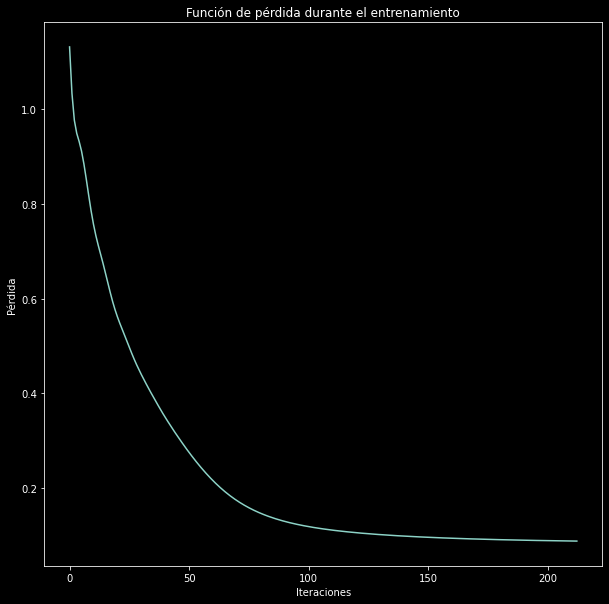

In [ ]:
#Graficar la función de pérdida
plt.figure(figsize=(10, 10))
plt.plot(mlp.loss_curve_)
plt.title('Función de pérdida durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.show()

## Predecir con la red más grande

Predicción sobre el mismo conjunto de test, ahora con la red entrenada en la celda anterior.

In [ ]:
#Predecir los datos del conjunto de prueba
y_pred = mlp.predict(X_test)
#print(y_pred)
#print(y_test)


## Exactitud de la red más grande

In [ ]:
#Calcular exactitud del modelo
accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Exactitud: {accuracy:.2f}%")

Exactitud: 96.67%


## Región de decisión de la red más grande

Misma lógica que antes: grilla sobre el plano y color según la clase que predice el modelo en cada punto.

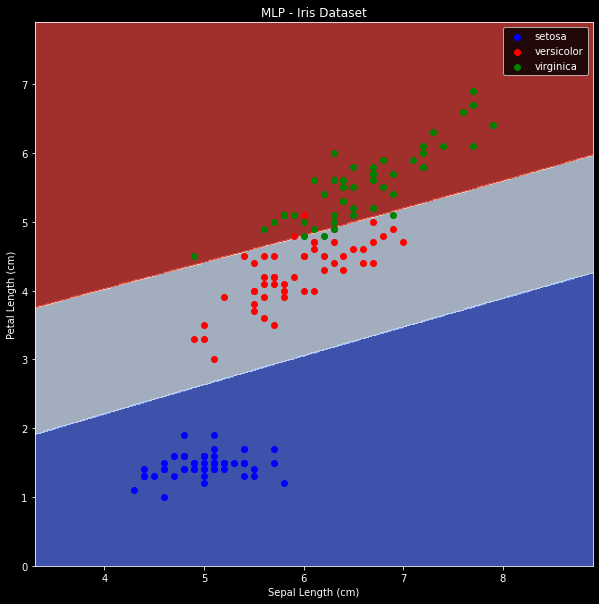

In [ ]:
# 4. Visualizar la región de decisión
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 500),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 500))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 10))
plt.contourf(xx, yy, Z, alpha=0.8, cmap="coolwarm")
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color="blue", label="setosa")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color="red", label="versicolor")
plt.scatter(X[y == 2][:, 0], X[y == 2][:, 1], color="green", label="virginica")
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.title("MLP - Iris Dataset")
plt.show()

## Barrido de `alpha` (regularización L2)

`alpha` es el coeficiente de regularización L2: penaliza pesos grandes en la red para reducir el sobreajuste. Valores más altos de `alpha` fuerzan pesos más chicos (modelo más simple, menos propenso a sobreajustar pero también menos flexible); valores más bajos dejan que la red ajuste libremente.

Acá se prueban 5 valores que cubren **cinco órdenes de magnitud**: de 0.00001 a 1.0. Vale la pena adelantar el resultado: las cinco corridas dan **la misma exactitud (0.97)**. Esto no es un error, es consecuencia de dos cosas del problema elegido:

- Iris con solo 2 atributos es un problema muy fácil de separar, así que el modelo está lejos de sobreajustar en cualquiera de los alphas probados.
- El conjunto de test tiene apenas **30 muestras**, así que la exactitud solo puede tomar valores como 29/30 = 0.9667 o 30/30 = 1.0: no hay resolución suficiente para que la regularización, aunque tenga algún efecto interno en los pesos, se note en esta métrica.

Para ver el efecto de `alpha` con más claridad haría falta un problema más difícil (más atributos, clases más solapadas) y/o un conjunto de test más grande.

In [ ]:
#Probar diferentes valores alpha
for alpha in [0.00001, 0.001, 0.01, 0.1, 1.0]:
    mlp = MLPClassifier(hidden_layer_sizes=(100,200,300), max_iter=400, activation='relu', random_state=42, alpha=alpha)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f'Alpha: {alpha}, Exactitud: {accuracy:.2f}')

Alpha: 1e-05, Exactitud: 0.97
Alpha: 0.001, Exactitud: 0.97
Alpha: 0.01, Exactitud: 0.97
Alpha: 0.1, Exactitud: 0.97
Alpha: 1.0, Exactitud: 0.97


c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


## Comparar solvers: SGD, Adam y LBFGS

Las próximas tres celdas entrenan la misma arquitectura simple (una capa de 100 neuronas) cambiando el **solver**, el algoritmo que optimiza los pesos de la red:

- **sgd** (descenso por gradiente estocástico): el clásico, actualiza los pesos con lotes chicos de datos (`batch_size=50` acá); con `momentum` acelera la convergencia en la dirección correcta. Requiere ajustar bien la tasa de aprendizaje.
- **adam**: versión adaptativa de SGD que ajusta la tasa de aprendizaje por cada peso automáticamente; suele ser una buena opción por defecto en redes de tamaño chico a mediano, y es el solver que usa `MLPClassifier` por defecto.
- **lbfgs**: un método de optimización de segundo orden (cuasi-Newton). No usa mini-batches, converge rápido en datasets chicos como este, pero no escala bien a datasets grandes.

Igual que con `alpha`, adelantamos el resultado: **los tres dan 0.97 de exactitud**. Con un problema tan simple y un test de 30 muestras, esta comparación sirve sobre todo para ver la sintaxis de cada solver, no para sacar conclusiones sobre cuál es "mejor" — para eso haría falta un problema donde los solvers realmente se diferencien.

Además, esta celda del solver `sgd` **no fija `random_state`**, a diferencia de las otras dos. Eso significa que esta celda puntual no es reproducible: cada vez que se ejecute puede dar un resultado levemente distinto (aunque con este problema tan fácil, probablemente siga rondando el mismo valor de exactitud).

In [ ]:
#Solver sgd
mlp_sgd = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, solver='sgd', learning_rate='constant', learning_rate_init=0.01, momentum=0.9, batch_size=50)
mlp_sgd.fit(X_train, y_train)
y_pred_sgd = mlp_sgd.predict(X_test)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
print(f'Accuracy sgd: {accuracy_sgd:.2f}')


Accuracy sgd: 0.97


### Solver `adam`

In [ ]:
#Solver adam
mlp_adam = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, solver='adam', random_state=42)
mlp_adam.fit(X_train, y_train)
y_pred_adam = mlp_adam.predict(X_test)
accuracy_adam = accuracy_score(y_test, y_pred_adam)
print(f'Accuracy adam: {accuracy_adam:.2f}')

Accuracy adam: 0.97


### Solver `lbfgs`

In [ ]:
#Solver lbfgs
mlp_lbfgs = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, solver='lbfgs', random_state=42)
mlp_lbfgs.fit(X_train, y_train)
y_pred_lbfgs = mlp_lbfgs.predict(X_test)
accuracy_lbfgs = accuracy_score(y_test, y_pred_lbfgs)
print(f'Accuracy lbfgs: {accuracy_lbfgs:.2f}')

Accuracy lbfgs: 0.97


## Grilla de hiperparámetros para `GridSearchCV`

Se define el espacio de búsqueda: 3 arquitecturas, 2 activaciones, 2 solvers, 2 valores de `alpha` y 2 estrategias de `learning_rate`. En la celda siguiente `GridSearchCV` va a probar **todas las combinaciones** (3x2x2x2x2 = 48) usando validación cruzada.

In [ ]:
param_ = {
    'hidden_layer_sizes': [(50, 50, 50), (50, 100, 50), (100,)],
    'activation':['tanh','relu'],
    'solver':['adam','sgd'],
    'alpha':[0.0001, 0.05],
    'learning_rate': ['constant','adaptive'],
}

## Búsqueda exhaustiva con validación cruzada (`GridSearchCV`)

`GridSearchCV` entrena y evalúa las 48 combinaciones de la grilla anterior, cada una con **validación cruzada de 5 pliegues** (`cv=5`): los datos de entrenamiento se dividen en 5 partes, se entrena con 4 y se valida con la restante, rotando, y se promedia el resultado. Esto da una estimación más confiable que un único split train/test, porque no depende de qué partición en particular tocó. `n_jobs=-1` usa todos los núcleos disponibles para paralelizar la búsqueda.

**Advertencia sobre esta celda:** el `MLPClassifier` base se crea con `max_iter=100`, un límite bajo para una red con hasta 3 capas ocultas de hasta 100 neuronas. Al ejecutar esta celda es esperable que aparezca un `ConvergenceWarning` avisando que varias combinaciones no llegaron a converger en esas 100 iteraciones. Esto tiene una consecuencia importante para interpretar el resultado: los candidatos no se están comparando en igualdad de condiciones de convergencia, así que el "mejor" combo que devuelve `grid_search.best_params_` puede reflejar más bien **cuál arquitectura aprende más rápido en pocas iteraciones**, no necesariamente cuál es la mejor arquitectura si a todas se les diera tiempo de converger del todo.

In [ ]:
#Grid Search

mlp = MLPClassifier(max_iter=100)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_, n_jobs=-1, cv=5)
grid_search.fit(X_train, y_train)
best_params_grid = grid_search.best_params_
print(best_params_grid)


{'activation': 'tanh', 'alpha': 0.05, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}


c:\Users\MSI\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
